# LAB Data: TTP (Time-To-Positive) Extraction & Alignment

Works on either `LAB_DDM_paper` or `LAB_OneToOne` raw source folders.

1. **Load** -- `exp_path`/`folder_idx` are parameters, reused from `01b_lab_curve_preprocessing.py`'s file registry.
2. **TTP extraction** -- for each curve, the first cycle where it reaches 10% of *its own* max value.
3. **TTP alignment** -- shift every curve left so its TTP lines up with the lowest TTP across all curves, then crop the tail so every curve ends up the same length (no padding/NaNs).
4. **Visualise** before vs after.

In [1]:
import os

try:
    notebook_path = globals().get('__vsc_ipynb_file__')
    if notebook_path:
        os.chdir(os.path.dirname(notebook_path))
except Exception as e:
    print(f"Could not change directory: {e}")

print("Current Working Directory:", os.getcwd())
%load_ext autoreload
%autoreload 2
%matplotlib inline

Current Working Directory: /vol/bitbucket/gk225/POC_DDM/gk_code/main


In [2]:
import re
import importlib.util
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import config

def _load_digit_module(name, path):
    spec = importlib.util.spec_from_file_location(name, path)
    mod = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(mod)
    return mod

lab01b = _load_digit_module("lab01b", "01b_lab_curve_preprocessing.py")

# Merge LAB_DDM_paper's registry (Z_area/Z_range/...) with LAB_OneToOne's (1_area/2_range/...)
# so the same loader works against either exp_path.
ALL_FILE_MAPPING = {**lab01b.FILE_MAPPING, **lab01b.FILE_MAPPING_ONE_TO_ONE}
ALL_FILE_TARGET = {**lab01b.FILE_TARGET, **lab01b.FILE_TARGET_ONE_TO_ONE}


[*] SUCCESS: TensorFlow is utilizing the GPU -> /physical_device:GPU:0



In [3]:
ALL_FILE_MAPPING

{'ACA_qdPCR': 'dPCR_Dataset_Pure.csv',
 'AMCA_qdPCR': 'dPCR_Amplification_Curves.csv',
 'AMCA_qdLAMP': '5Plex_dLAMP_oldData.csv',
 'Z_area': 'area_strategy.csv',
 'Z_range': 'range_strategy.xlsx',
 'Z_range_filtered': 'range_strategy_filtered.xlsx',
 '1_area': 'area_strategy.csv',
 '2_range': 'range_strategy.xlsx',
 '3_range_filtered': 'range_strategy_filtered.xlsx'}

## 1. Load Data

`exp_path`/`folder_idx` are parameters -- swap between `config.LAB_EXP_FOLDER` (LAB_DDM_paper) and `config.LAB_1TO1_EXP_FOLDER` (LAB_OneToOne) freely.

In [4]:
def load_curves(exp_path, folder_idx):
    """Read the raw CSV/Excel for the folder at folder_idx. Returns (curves, timestamps, well_labels, folder_name)."""
    folder_names = sorted([
        name for name in os.listdir(exp_path)
        if os.path.isdir(os.path.join(exp_path, name)) and name in ALL_FILE_MAPPING
    ])
    if folder_idx >= len(folder_names):
        raise IndexError(f"folder_idx {folder_idx} out of bounds for {len(folder_names)} folders: {folder_names}")
    folder_name = folder_names[folder_idx]
    file_path = os.path.join(exp_path, folder_name, ALL_FILE_MAPPING[folder_name])
    df = lab01b._read_table(file_path)

    cycle_cols = [col for col in df.columns
                  if str(col).startswith("Cycle") or re.match(r'^\d+(\.\d+)?$', str(col))]
    sorted_cycle_cols = sorted(cycle_cols, key=lab01b.get_numeric_sort_key)
    timestamps = np.array([lab01b.get_numeric_sort_key(c) for c in sorted_cycle_cols])

    curves = df[sorted_cycle_cols].to_numpy().astype(np.float64)
    well_labels = df[ALL_FILE_TARGET[folder_name]].to_numpy()
    return curves, timestamps, well_labels, folder_name

In [46]:
EXP_PATH = config.LAB_EXP_FOLDER
FOLDER_IDX = 5

curves, timestamps, well_labels, folder_name = load_curves(EXP_PATH, FOLDER_IDX)
print(f"Loaded '{folder_name}': curves {curves.shape}, targets {sorted(set(well_labels))}")

Loaded 'Z_range_filtered': curves (12135, 35), targets ['Pf', 'Pk', 'Pm', 'Po', 'Pv']


## 2. TTP Extraction

TTP = first cycle index where a curve reaches 10% of *its own* max value.

In [47]:
def compute_ttp(curves, threshold_frac=0.1):
    max_vals = curves.max(axis=1, keepdims=True)
    min_vals = curves[:, 0][..., np.newaxis]
    range_vals = max_vals - min_vals
    threshold_vals = min_vals + range_vals * threshold_frac
    reached = curves > threshold_vals
    return np.argmax(reached, axis=1)

In [48]:
ttp_idx = compute_ttp(curves, threshold_frac=0.1)
print(f"TTP index range: {ttp_idx.min()} - {ttp_idx.max()} (cycles {timestamps[ttp_idx.min()]:.0f}-{timestamps[ttp_idx.max()]:.0f})")

TTP index range: 2 - 32 (cycles 3-33)


## 3. TTP Alignment

Shift each curve left by `(its TTP - the minimum TTP)`, then crop every curve's tail to the shortest
resulting length (`n_cycles - max_shift`) so all curves end up the same length with no NaN padding.

Note: a single very-late-TTP curve can dominate `max_shift` and collapse the post-alignment length for
*every* curve -- check `aligned.shape` below before relying on this for downstream modelling.

In [49]:
def align_by_ttp(curves, timestamps, ttp_idx):
    """Shift each curve so its TTP lines up with the minimum TTP, then crop to a common length."""
    min_ttp = int(ttp_idx.min())
    shifts = ttp_idx - min_ttp
    max_shift = int(shifts.max())
    final_len = curves.shape[1] - max_shift

    aligned = np.empty((curves.shape[0], final_len))
    for i in range(curves.shape[0]):
        s = int(shifts[i])
        aligned[i] = curves[i, s:s + final_len]

    aligned_timestamps = timestamps[:final_len]
    return aligned, aligned_timestamps, min_ttp

In [50]:
aligned, aligned_timestamps, min_ttp = align_by_ttp(curves, timestamps, ttp_idx)
print(f"Aligned shape: {aligned.shape} (from {curves.shape}) | min_ttp index: {min_ttp}")

Aligned shape: (12135, 5) (from (12135, 35)) | min_ttp index: 2


## 4. Visualise Before vs After

In [62]:
def plot_before_after_alignment(curves, timestamps, ttp_idx, well_labels, max_ttp=None, title=""):
    curves_before, well_labels_before = curves, well_labels

    if max_ttp is not None:
        keep = ttp_idx <= max_ttp
        curves_after_raw = curves[keep]
        well_labels_after = well_labels[keep]
        ttp_idx_after = ttp_idx[keep]
    else:
        curves_after_raw = curves
        well_labels_after = well_labels
        ttp_idx_after = ttp_idx

    min_ttp = int(ttp_idx_after.min())
    shifts = ttp_idx_after - min_ttp
    max_shift = int(shifts.max())
    final_len = curves_after_raw.shape[1] - max_shift

    aligned = np.empty((curves_after_raw.shape[0], final_len))
    for i in range(curves_after_raw.shape[0]):
        s = int(shifts[i])
        aligned[i] = curves_after_raw[i, s:s + final_len]
    aligned_timestamps = timestamps[:final_len]

    baseline_corrected = aligned - aligned[:, [0]]

    # --- NEW: Calculate 0-1 Normalized curves from the baseline_corrected data ---
    mins = baseline_corrected.min(axis=1, keepdims=True)
    maxs = baseline_corrected.max(axis=1, keepdims=True)
    ranges = np.where((maxs - mins) == 0, 1, maxs - mins) # Prevent division by zero
    normalized_curves = (baseline_corrected - mins) / ranges

    targets_before = sorted(set(well_labels_before))
    targets_after = sorted(set(well_labels_after))
    all_targets = sorted(set(targets_before) | set(targets_after))
    cmap = plt.get_cmap("tab10")
    color_map = {t: cmap(i % 10) for i, t in enumerate(all_targets)}

    # CHANGED: 4 subplots instead of 3, wider figsize to accommodate
    fig, axes = plt.subplots(1, 4, figsize=(26, 6), sharey=False)

    ax = axes[0]
    for t in targets_before:
        mask = well_labels_before == t
        for row in curves_before[mask]:
            ax.plot(timestamps, row, color=color_map[t], lw=0.3, alpha=0.15)
    ax.set_title(f"Before TTP Alignment{title}", fontweight="bold")
    ax.set_xlabel("Cycle")
    ax.grid(alpha=0.3)
    handles = [plt.Line2D([0], [0], color=color_map[t], lw=2, label=f"{t} (n={(well_labels_before==t).sum()})") for t in targets_before]
    ax.legend(handles=handles, loc="upper right", title="Target", fontsize=8)
    ax.set_ylabel("Signal")

    ax = axes[1]
    for t in targets_after:
        mask = well_labels_after == t
        for row in aligned[mask]:
            ax.plot(aligned_timestamps, row, color=color_map[t], lw=0.3, alpha=0.15)
    ax.set_title(f"After TTP Alignment{title}", fontweight="bold")
    ax.set_xlabel("Cycle")
    ax.grid(alpha=0.3)
    handles = [plt.Line2D([0], [0], color=color_map[t], lw=2, label=f"{t} (n={(well_labels_after==t).sum()})") for t in targets_after]
    ax.legend(handles=handles, loc="upper right", title="Target", fontsize=8)

    ax = axes[2]
    for t in targets_after:
        mask = well_labels_after == t
        for row in baseline_corrected[mask]:
            ax.plot(aligned_timestamps, row, color=color_map[t], lw=0.3, alpha=0.15)
    ax.set_title(f"After + Baseline Corrected{title}", fontweight="bold")
    ax.set_xlabel("Cycle")
    ax.grid(alpha=0.3)
    handles = [plt.Line2D([0], [0], color=color_map[t], lw=2, label=f"{t} (n={(well_labels_after==t).sum()})") for t in targets_after]
    ax.legend(handles=handles, loc="upper right", title="Target", fontsize=8)

    # --- NEW: 4th Plot for 0-1 Normalized curves ---
    ax = axes[3]
    for t in targets_after:
        mask = well_labels_after == t
        for row in normalized_curves[mask]:
            ax.plot(aligned_timestamps, row, color=color_map[t], lw=0.3, alpha=0.15)
    ax.set_title(f"0-1 Normalized{title}", fontweight="bold")
    ax.set_xlabel("Cycle")
    ax.grid(alpha=0.3)
    handles = [plt.Line2D([0], [0], color=color_map[t], lw=2, label=f"{t} (n={(well_labels_after==t).sum()})") for t in targets_after]
    ax.legend(handles=handles, loc="upper right", title="Target", fontsize=8)

    plt.tight_layout()
    plt.show()

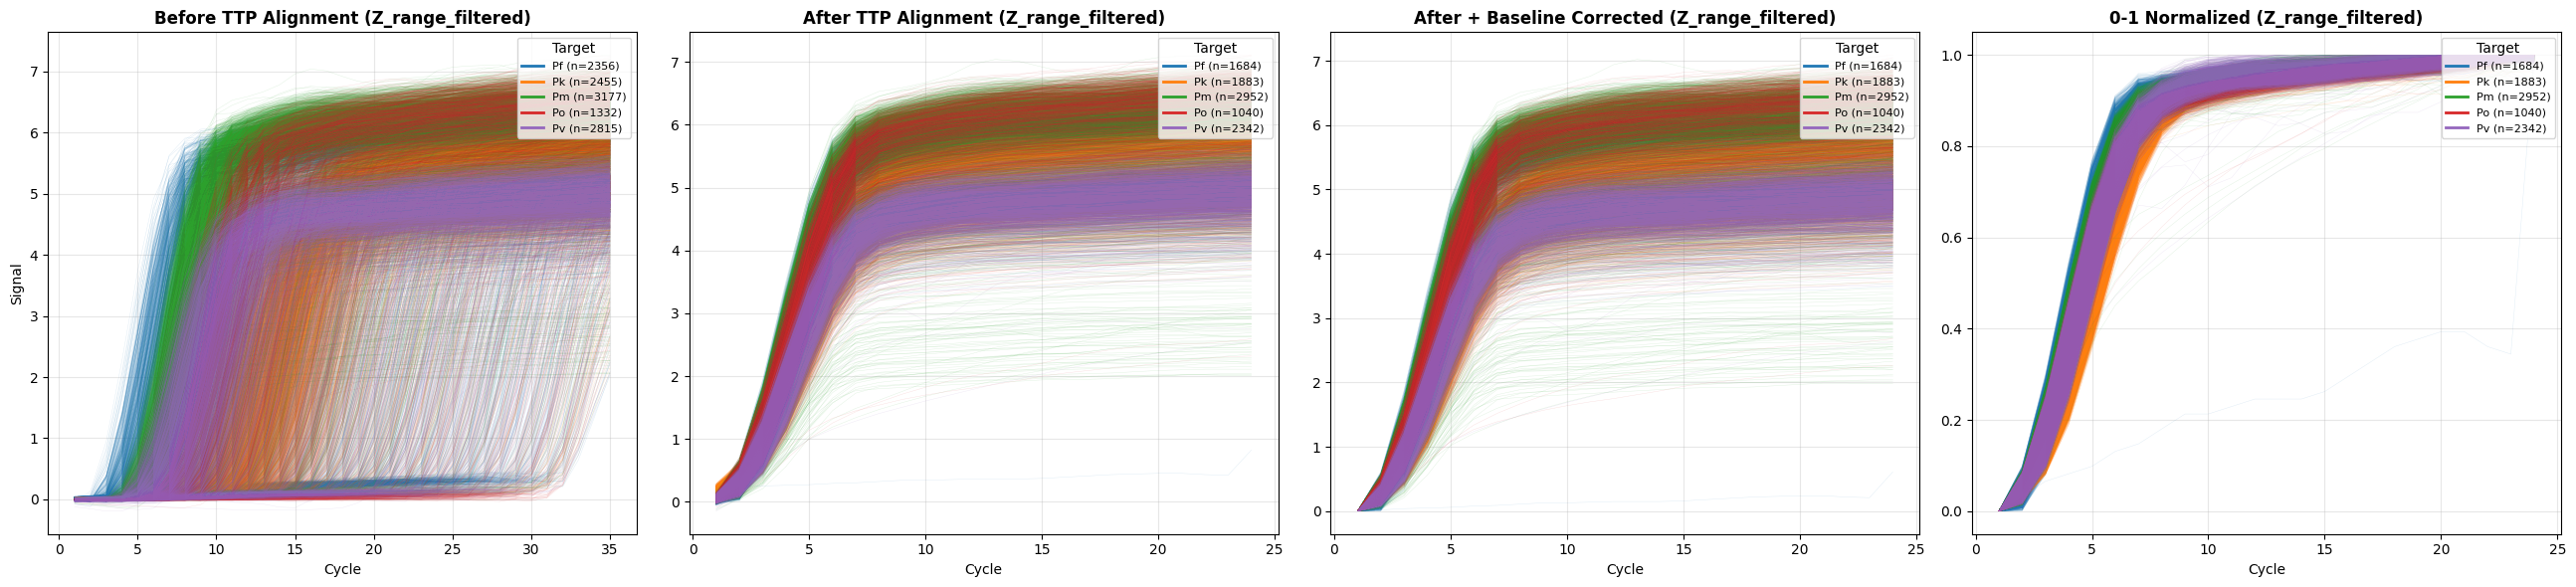

In [67]:
plot_before_after_alignment(curves, timestamps, ttp_idx, well_labels, max_ttp=13, title=f" ({folder_name})")

In [59]:
import pandas as pd

def build_ttp_retention_table(ttp_idx, well_labels, timestamps):
    unique_ttps = sorted(set(ttp_idx.tolist()))
    targets = sorted(set(well_labels))
    min_ttp = min(unique_ttps)
    n_cycles = len(timestamps)
    total_counts = {t: int((well_labels == t).sum()) for t in targets}

    rows = []
    index = []
    for max_ttp in unique_ttps:
        keep = ttp_idx <= max_ttp
        cycles_left = n_cycles - (max_ttp - min_ttp)
        index.append(f"max_ttp={max_ttp+1} (cycles_left={cycles_left} ({cycles_left*100/max(timestamps):.2f}%))")
        row = {}
        for t in targets:
            n_preserved = int(((well_labels == t) & keep).sum())
            pct = 100 * n_preserved / total_counts[t] if total_counts[t] else 0
            row[t] = f"{n_preserved} ({pct:.1f}%)"
        rows.append(row)

    return pd.DataFrame(rows, index=index)


table = build_ttp_retention_table(ttp_idx, well_labels, timestamps)
table


,Pf,Pk,Pm,Po,Pv
max_ttp=3 (cycles_left=35 (100.00%)),8 (0.3%),0 (0.0%),0 (0.0%),0 (0.0%),0 (0.0%)
max_ttp=4 (cycles_left=34 (97.14%)),166 (7.0%),0 (0.0%),1 (0.0%),0 (0.0%),0 (0.0%)
max_ttp=5 (cycles_left=33 (94.29%)),505 (21.4%),0 (0.0%),119 (3.7%),0 (0.0%),30 (1.1%)
max_ttp=6 (cycles_left=32 (91.43%)),788 (33.4%),0 (0.0%),1107 (34.8%),5 (0.4%),358 (12.7%)
max_ttp=7 (cycles_left=31 (88.57%)),1003 (42.6%),0 (0.0%),2002 (63.0%),90 (6.8%),963 (34.2%)
max_ttp=8 (cycles_left=30 (85.71%)),1156 (49.1%),5 (0.2%),2438 (76.7%),328 (24.6%),1509 (53.6%)
max_ttp=9 (cycles_left=29 (82.86%)),1276 (54.2%),58 (2.4%),2651 (83.4%),584 (43.8%),1824 (64.8%)
max_ttp=10 (cycles_left=28 (80.00%)),1385 (58.8%),245 (10.0%),2759 (86.8%),790 (59.3%),2015 (71.6%)
max_ttp=11 (cycles_left=27 (77.14%)),1473 (62.5%),635 (25.9%),2833 (89.2%),891 (66.9%),2131 (75.7%)
max_ttp=12 (cycles_left=26 (74.29%)),1535 (65.2%),1149 (46.8%),2873 (90.4%),947 (71.1%),2217 (78.8%)


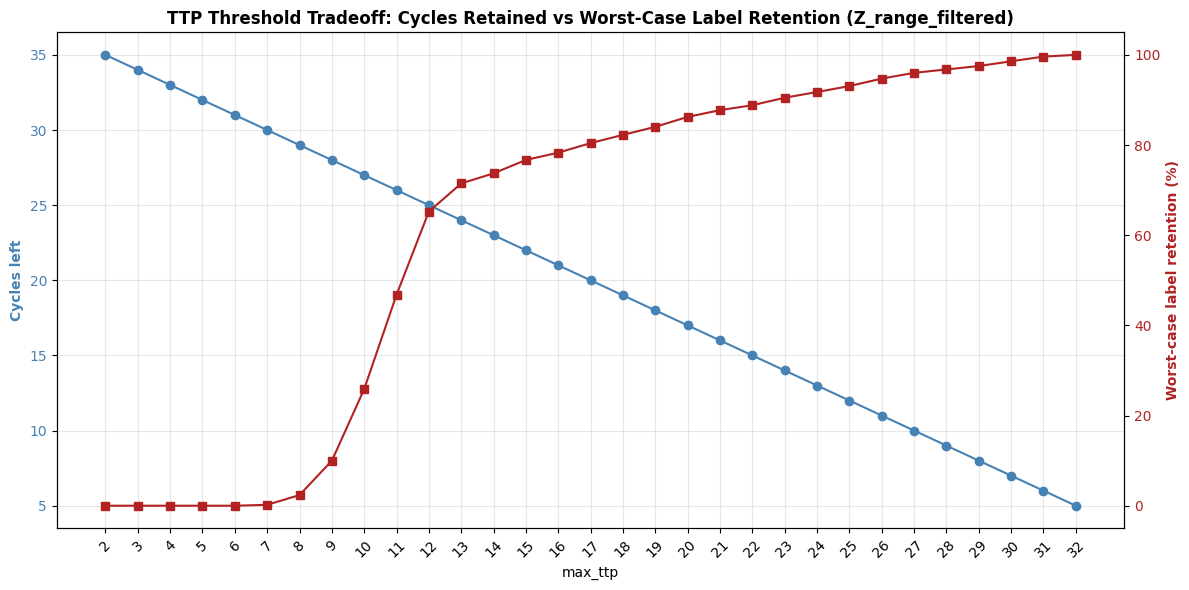

In [54]:
def plot_ttp_tradeoff(ttp_idx, well_labels, timestamps, title=""):
    unique_ttps = sorted(set(ttp_idx.tolist()))
    targets = sorted(set(well_labels))
    min_ttp = min(unique_ttps)
    n_cycles = len(timestamps)
    total_counts = {t: int((well_labels == t).sum()) for t in targets}

    cycles_left_list, min_retention_list = [], []
    for max_ttp in unique_ttps:
        keep = ttp_idx <= max_ttp
        cycles_left = n_cycles - (max_ttp - min_ttp)
        retentions = [100 * int(((well_labels == t) & keep).sum()) / total_counts[t] for t in targets]
        cycles_left_list.append(cycles_left)
        min_retention_list.append(min(retentions))

    x_positions = range(1, len(unique_ttps) + 1)

    fig, ax1 = plt.subplots(figsize=(12, 6))
    ax1.plot(x_positions, cycles_left_list, color="steelblue", marker="o", label="Cycles left")
    ax1.set_xlabel("max_ttp")
    ax1.set_ylabel("Cycles left", color="steelblue", fontweight="bold")
    ax1.tick_params(axis="y", labelcolor="steelblue")
    ax1.set_xticks(list(x_positions))
    ax1.set_xticklabels(unique_ttps, rotation=45)

    ax2 = ax1.twinx()
    ax2.plot(x_positions, min_retention_list, color="firebrick", marker="s", label="Worst-case label retention (%)")
    ax2.set_ylabel("Worst-case label retention (%)", color="firebrick", fontweight="bold")
    ax2.tick_params(axis="y", labelcolor="firebrick")

    ax1.set_title(f"TTP Threshold Tradeoff: Cycles Retained vs Worst-Case Label Retention{title}", fontweight="bold")
    ax1.grid(alpha=0.3)
    fig.tight_layout()
    plt.show()
    return unique_ttps, cycles_left_list, min_retention_list

unique_ttps, cycles_left_list, min_retention_list = plot_ttp_tradeoff(ttp_idx, well_labels, timestamps, title=f" ({folder_name})")


In [55]:
def _ttp_tradeoff_curve(ttp_idx, well_labels, timestamps):
    """Shared helper: (unique_ttps, cycles_left, worst_case_retention_pct) arrays."""
    unique_ttps = sorted(set(ttp_idx.tolist()))
    targets = sorted(set(well_labels))
    min_ttp = min(unique_ttps)
    n_cycles = len(timestamps)
    total_counts = {t: int((well_labels == t).sum()) for t in targets}

    cycles_left_list, min_retention_list = [], []
    for max_ttp in unique_ttps:
        keep = ttp_idx <= max_ttp
        cycles_left = n_cycles - (max_ttp - min_ttp)
        retentions = [100 * int(((well_labels == t) & keep).sum()) / total_counts[t] for t in targets]
        cycles_left_list.append(cycles_left)
        min_retention_list.append(min(retentions))
    return np.array(unique_ttps), np.array(cycles_left_list), np.array(min_retention_list)


# --- Option 1: threshold rule ---
def choose_max_ttp_by_threshold(ttp_idx, well_labels, timestamps, min_retention_pct=80):
    """Smallest max_ttp such that worst-case label retention >= min_retention_pct."""
    unique_ttps, cycles_left, min_retention = _ttp_tradeoff_curve(ttp_idx, well_labels, timestamps)
    ok = min_retention >= min_retention_pct
    if not ok.any():
        raise ValueError(f"No max_ttp reaches {min_retention_pct}% retention (max achievable: {min_retention.max():.1f}%)")
    idx = np.argmax(ok)  # first True
    return int(unique_ttps[idx]), int(cycles_left[idx]), float(min_retention[idx])


# --- Option 2: combined score (cycles_left * worst_case_retention) ---
def choose_max_ttp_by_score(ttp_idx, well_labels, timestamps):
    """max_ttp maximizing cycles_left * worst_case_retention_pct."""
    unique_ttps, cycles_left, min_retention = _ttp_tradeoff_curve(ttp_idx, well_labels, timestamps)
    score = cycles_left * min_retention
    idx = int(np.argmax(score))
    return int(unique_ttps[idx]), int(cycles_left[idx]), float(min_retention[idx])


# --- Option 3: knee/elbow detection (max perpendicular distance from the line endpoints) ---
def choose_max_ttp_by_knee(ttp_idx, well_labels, timestamps):
    """max_ttp at the 'knee' of the cycles_left-vs-retention tradeoff curve."""
    unique_ttps, cycles_left, min_retention = _ttp_tradeoff_curve(ttp_idx, well_labels, timestamps)
    x = (unique_ttps - unique_ttps.min()) / (unique_ttps.max() - unique_ttps.min())
    y = (min_retention - min_retention.min()) / (min_retention.max() - min_retention.min() + 1e-9)
    p1, p2 = np.array([x[0], y[0]]), np.array([x[-1], y[-1]])
    line_vec_norm = (p2 - p1) / np.linalg.norm(p2 - p1)
    points = np.stack([x, y], axis=1)
    vecs = points - p1
    proj_points = p1 + np.outer(vecs @ line_vec_norm, line_vec_norm)
    dist = np.linalg.norm(points - proj_points, axis=1)
    idx = int(np.argmax(dist))
    return int(unique_ttps[idx]), int(cycles_left[idx]), float(min_retention[idx])


In [56]:
for label, fn in [
    ("1. Threshold (>=80% retention)", lambda: choose_max_ttp_by_threshold(ttp_idx, well_labels, timestamps, 80)),
    ("2. Combined score (cycles*retention)", lambda: choose_max_ttp_by_score(ttp_idx, well_labels, timestamps)),
    ("3. Knee/elbow detection", lambda: choose_max_ttp_by_knee(ttp_idx, well_labels, timestamps)),
]:
    max_ttp, cycles_left, retention = fn()
    print(f"{label:42s} -> max_ttp={max_ttp:3d}  cycles_left={cycles_left:3d}  worst_retention={retention:5.1f}%")


1. Threshold (>=80% retention)             -> max_ttp= 17  cycles_left= 20  worst_retention= 80.4%
2. Combined score (cycles*retention)       -> max_ttp= 13  cycles_left= 24  worst_retention= 71.5%
3. Knee/elbow detection                    -> max_ttp= 13  cycles_left= 24  worst_retention= 71.5%


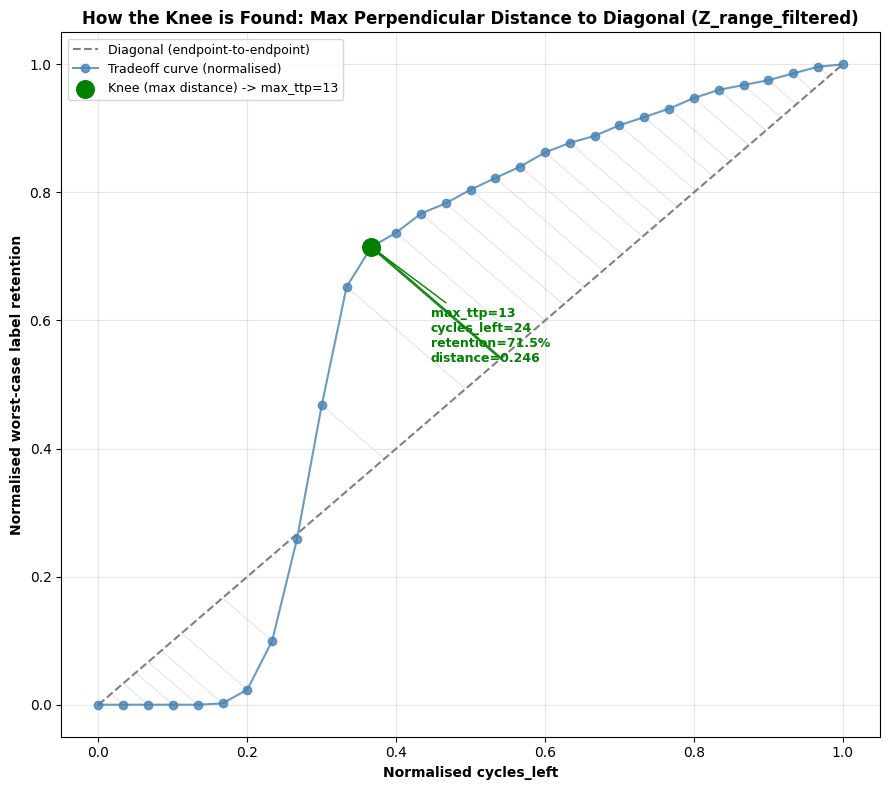

In [66]:
def plot_knee_explainer(ttp_idx, well_labels, timestamps, title=""):
    """Visualises HOW the knee is found: normalise (cycles_left, retention) to [0,1], draw
    the diagonal connecting the curve's endpoints, then show each point's perpendicular
    distance to that diagonal -- the knee is the point with the MAX perpendicular distance."""
    unique_ttps, cycles_left, min_retention = _ttp_tradeoff_curve(ttp_idx, well_labels, timestamps)

    x = 1-(cycles_left - cycles_left.min()) / (cycles_left.max() - cycles_left.min() + 1e-9)
    y = (min_retention - min_retention.min()) / (min_retention.max() - min_retention.min() + 1e-9)
    p1, p2 = np.array([x[0], y[0]]), np.array([x[-1], y[-1]])
    line_vec_norm = (p2 - p1) / np.linalg.norm(p2 - p1)
    points = np.stack([x, y], axis=1)
    vecs = points - p1
    proj_points = p1 + np.outer(vecs @ line_vec_norm, line_vec_norm)
    dist = np.linalg.norm(points - proj_points, axis=1)
    knee_idx = int(np.argmax(dist))

    fig, ax = plt.subplots(figsize=(9, 8))
    ax.plot([p1[0], p2[0]], [p1[1], p2[1]], color="gray", linestyle="--", lw=1.5, label="Diagonal (endpoint-to-endpoint)")
    ax.plot(x, y, color="steelblue", marker="o", lw=1.5, alpha=0.8, label="Tradeoff curve (normalised)")

    for i in range(len(x)):
        style = dict(color="green", lw=2, alpha=0.9) if i == knee_idx else dict(color="lightgray", lw=0.8, alpha=0.6)
        ax.plot([x[i], proj_points[i, 0]], [y[i], proj_points[i, 1]], **style, zorder=1)

    ax.scatter(x[knee_idx], y[knee_idx], color="green", s=160, zorder=5, label=f"Knee (max distance) -> max_ttp={unique_ttps[knee_idx]}")
    ax.annotate(
        f"max_ttp={unique_ttps[knee_idx]}\ncycles_left={cycles_left[knee_idx]}\nretention={min_retention[knee_idx]:.1f}%\ndistance={dist[knee_idx]:.3f}",
        xy=(x[knee_idx], y[knee_idx]), xytext=(x[knee_idx] + 0.08, y[knee_idx] - 0.18),
        color="green", fontsize=9, fontweight="bold",
        arrowprops=dict(arrowstyle="->", color="green"),
    )

    ax.set_xlabel("Normalised cycles_left", fontweight="bold")
    ax.set_ylabel("Normalised worst-case label retention", fontweight="bold")
    ax.set_title(f"How the Knee is Found: Max Perpendicular Distance to Diagonal{title}", fontweight="bold")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_knee_explainer(ttp_idx, well_labels, timestamps, title=f" ({folder_name})")


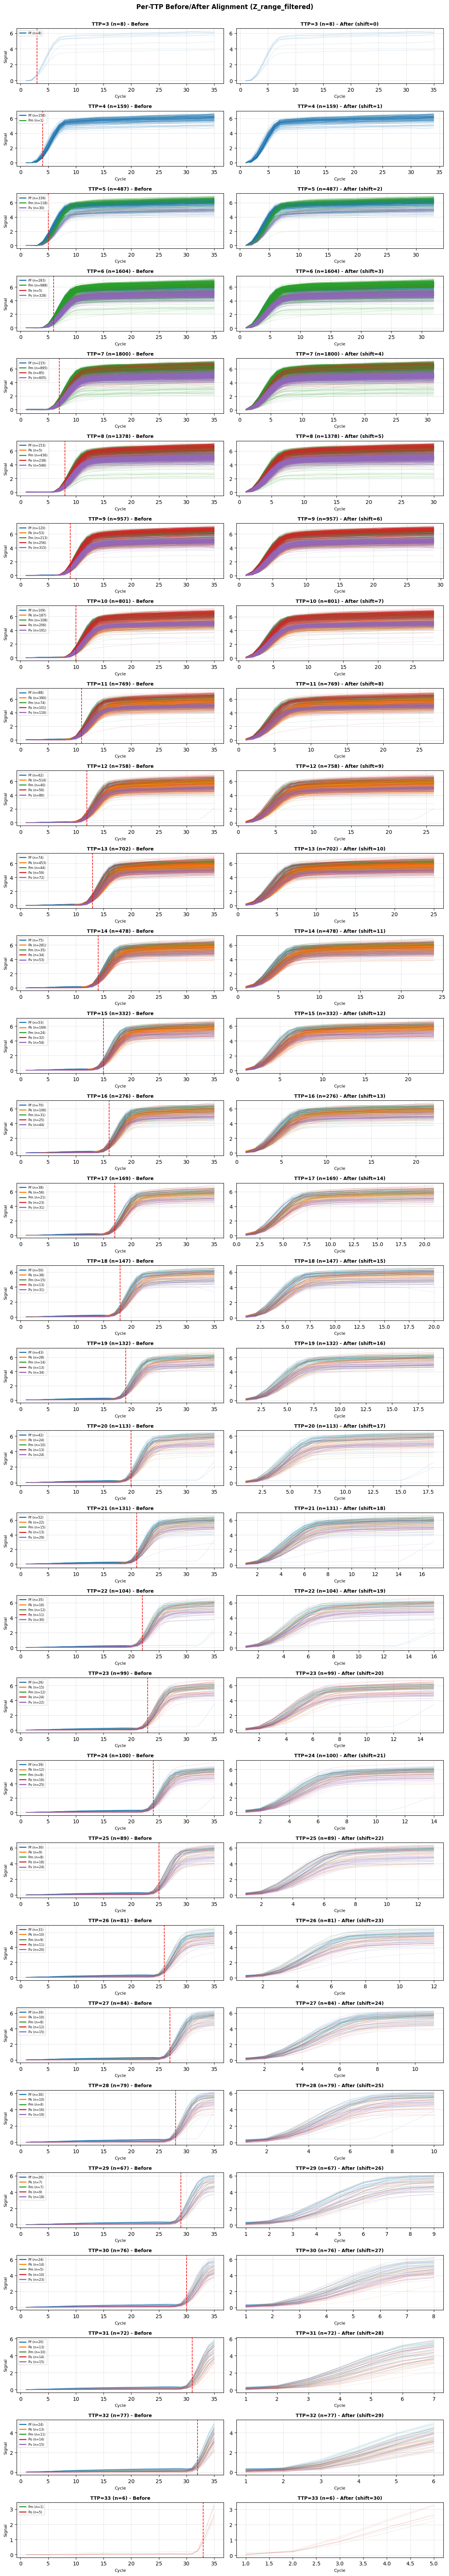

In [57]:
def plot_before_after_by_ttp(curves, timestamps, ttp_idx, well_labels, title=""):
    unique_ttps = sorted(set(ttp_idx.tolist()))
    targets = sorted(set(well_labels))
    cmap = plt.get_cmap("tab10")
    color_map = {t: cmap(i % 10) for i, t in enumerate(targets)}
    min_ttp = min(unique_ttps)

    n_rows = len(unique_ttps)
    fig, axes = plt.subplots(n_rows, 2, figsize=(12, 2.2 * n_rows), squeeze=False)
    for i, ttp in enumerate(unique_ttps):
        mask = ttp_idx == ttp
        shift = ttp - min_ttp
        ax_before, ax_after = axes[i, 0], axes[i, 1]
        after_timestamps = timestamps[:len(timestamps) - shift]
        row_handles = []
        for t in targets:
            t_mask = mask & (well_labels == t)
            if not t_mask.any():
                continue
            for row in curves[t_mask]:
                ax_before.plot(timestamps, row, lw=0.4, alpha=0.3, color=color_map[t])
            for row in curves[t_mask]:
                ax_after.plot(after_timestamps, row[shift:], lw=0.4, alpha=0.3, color=color_map[t])
            row_handles.append(plt.Line2D([0], [0], color=color_map[t], lw=2, label=f"{t} (n={t_mask.sum()})"))
        ax_before.axvline(timestamps[ttp], color="red", linestyle="--", lw=1.2)
        ax_before.set_title(f"TTP={ttp+1} (n={mask.sum()}) - Before", fontsize=9, fontweight="bold")
        ax_after.set_title(f"TTP={ttp+1} (n={mask.sum()}) - After (shift={shift})", fontsize=9, fontweight="bold")
        ax_before.set_ylabel("Signal", fontsize=8)
        ax_before.set_xlabel("Cycle", fontsize=8)
        ax_after.set_xlabel("Cycle", fontsize=8)
        ax_before.grid(alpha=0.3)
        ax_after.grid(alpha=0.3)
        ax_before.legend(handles=row_handles, fontsize=6, loc="upper left", framealpha=0.7)

    fig.suptitle(f"Per-TTP Before/After Alignment{title}", fontweight="bold", y=1.0)
    plt.tight_layout()
    plt.show()


plot_before_after_by_ttp(curves, timestamps, ttp_idx, well_labels, title=f" ({folder_name})")
